In [1]:
#import packages

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d


In [2]:
#Import the Weekly Progress Data from USDA NASS

file_path = "/group/moniergrp/dbaral/run_project/input_data/planting_harvest"
df = pd.read_csv(file_path + "/planting_harvest_usda.csv")
df.head()

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,...,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Value,CV (%)
0,SURVEY,2025,WEEK #14,4/6/25,STATE,CALIFORNIA,6,NaN,NaN,NaN,...,NaN,NaN,0,NaN,RICE,"RICE - PROGRESS, MEASURED IN PCT EMERGED",TOTAL,NOT SPECIFIED,0,NaN
1,SURVEY,2025,WEEK #15,4/13/25,STATE,CALIFORNIA,6,NaN,NaN,NaN,...,NaN,NaN,0,NaN,RICE,"RICE - PROGRESS, MEASURED IN PCT EMERGED",TOTAL,NOT SPECIFIED,0,NaN
2,SURVEY,2025,WEEK #16,4/20/25,STATE,CALIFORNIA,6,NaN,NaN,NaN,...,NaN,NaN,0,NaN,RICE,"RICE - PROGRESS, MEASURED IN PCT EMERGED",TOTAL,NOT SPECIFIED,0,NaN
3,SURVEY,2025,WEEK #17,4/27/25,STATE,CALIFORNIA,6,NaN,NaN,NaN,...,NaN,NaN,0,NaN,RICE,"RICE - PROGRESS, MEASURED IN PCT EMERGED",TOTAL,NOT SPECIFIED,0,NaN
4,SURVEY,2025,WEEK #18,5/4/25,STATE,CALIFORNIA,6,NaN,NaN,NaN,...,NaN,NaN,0,NaN,RICE,"RICE - PROGRESS, MEASURED IN PCT EMERGED",TOTAL,NOT SPECIFIED,0,NaN


In [3]:
#Filter for relevant columns
cols = ["Program", "Year", "Period", "Week Ending", "Data Item", "Value"]
df_new = df.filter(cols).copy()
df_new.head()

,Program,Year,Period,Week Ending,Data Item,Value
0,SURVEY,2025,WEEK #14,4/6/25,"RICE - PROGRESS, MEASURED IN PCT EMERGED",0
1,SURVEY,2025,WEEK #15,4/13/25,"RICE - PROGRESS, MEASURED IN PCT EMERGED",0
2,SURVEY,2025,WEEK #16,4/20/25,"RICE - PROGRESS, MEASURED IN PCT EMERGED",0
3,SURVEY,2025,WEEK #17,4/27/25,"RICE - PROGRESS, MEASURED IN PCT EMERGED",0
4,SURVEY,2025,WEEK #18,5/4/25,"RICE - PROGRESS, MEASURED IN PCT EMERGED",0


In [4]:
#Creating mask to filter data values for Planting and Harvest Progress from Data Item Column
mask = (df_new["Data Item"] == "RICE - PROGRESS, MEASURED IN PCT PLANTED") | (df_new['Data Item'] == 'RICE - PROGRESS, MEASURED IN PCT HARVESTED')
final_df = df_new[mask]
final_df.head()

,Program,Year,Period,Week Ending,Data Item,Value
307,SURVEY,2025,WEEK #31,8/3/25,"RICE - PROGRESS, MEASURED IN PCT HARVESTED",0
308,SURVEY,2025,WEEK #32,8/10/25,"RICE - PROGRESS, MEASURED IN PCT HARVESTED",0
309,SURVEY,2025,WEEK #33,8/17/25,"RICE - PROGRESS, MEASURED IN PCT HARVESTED",0
310,SURVEY,2025,WEEK #34,8/24/25,"RICE - PROGRESS, MEASURED IN PCT HARVESTED",0
311,SURVEY,2024,WEEK #31,8/4/24,"RICE - PROGRESS, MEASURED IN PCT HARVESTED",0


In [5]:
#Rename columns and Data Item
final_df = final_df.rename(columns={'Value': 'Progress'})
final_df['Data Item'] = final_df['Data Item'].str.replace('RICE - PROGRESS, MEASURED IN PCT PLANTED', 'PLANTING')
final_df['Data Item'] = final_df['Data Item'].str.replace('RICE - PROGRESS, MEASURED IN PCT HARVESTED', 'HARVEST')

#filter for Progress = 0
final_df = final_df[final_df['Progress'] != 0]
final_df.head()

,Program,Year,Period,Week Ending,Data Item,Progress
316,SURVEY,2024,WEEK #36,9/8/24,HARVEST,2
317,SURVEY,2024,WEEK #37,9/15/24,HARVEST,15
318,SURVEY,2024,WEEK #38,9/22/24,HARVEST,20
319,SURVEY,2024,WEEK #39,9/29/24,HARVEST,25
320,SURVEY,2024,WEEK #40,10/6/24,HARVEST,45


In [6]:
#filter the dataframe to find the pair of row that can be used to interpolate 50% progress value

filtered_data = []

for year in final_df['Year'].unique():
    df_year = final_df[final_df['Year'] == year]

    for data_item in ['HARVEST', 'PLANTING']:
        df_item = df_year[df_year['Data Item'] == data_item].sort_values(by='Progress')

        # Find consecutive pairs where the first value is < 50 and the second is >= 50
        progress_values = df_item['Progress'].tolist()
        week_ending_values = df_item['Week Ending'].tolist()

        found_pairs_indices = []
        for i in range(len(progress_values) - 1):
            if progress_values[i] < 50 and progress_values[i+1] >= 50:
                # Append the indices of the two rows to keep
                found_pairs_indices.append(df_item.index[i])
                found_pairs_indices.append(df_item.index[i+1])


        # Filter the original dataframe for rows that contain these progress values in the current year and data item
        if found_pairs_indices:
            filtered_data.append(final_df.loc[found_pairs_indices])

filtered_df = pd.concat(filtered_data).drop_duplicates().reset_index(drop=True)
display(filtered_df)

,Program,Year,Period,Week Ending,Data Item,Progress
0,SURVEY,2024,WEEK #40,10/6/24,HARVEST,45
1,SURVEY,2024,WEEK #41,10/13/24,HARVEST,60
2,SURVEY,2024,WEEK #19,5/12/24,PLANTING,30
3,SURVEY,2024,WEEK #20,5/19/24,PLANTING,70
4,SURVEY,2023,WEEK #41,10/15/23,HARVEST,45
...,...,...,...,...,...,...
105,SURVEY,1998,WEEK #41,10/11/98,HARVEST,55
106,SURVEY,1998,WEEK #21,5/24/98,PLANTING,45
107,SURVEY,1998,WEEK #22,5/31/98,PLANTING,60
108,SURVEY,2025,WEEK #19,5/11/25,PLANTING,40


In [7]:
#Change the object type to categorical dtype

filtered_df['Data Item'] = pd.Categorical(filtered_df['Data Item'], categories=['PLANTING', 'HARVEST'], ordered=True)
filtered_df = filtered_df.sort_values(by=['Year', 'Data Item']).reset_index(drop=True)
display(filtered_df)

,Program,Year,Period,Week Ending,Data Item,Progress
0,SURVEY,1998,WEEK #21,5/24/98,PLANTING,45
1,SURVEY,1998,WEEK #22,5/31/98,PLANTING,60
2,SURVEY,1998,WEEK #40,10/4/98,HARVEST,30
3,SURVEY,1998,WEEK #41,10/11/98,HARVEST,55
4,SURVEY,1999,WEEK #17,5/2/99,PLANTING,20
...,...,...,...,...,...,...
105,SURVEY,2024,WEEK #20,5/19/24,PLANTING,70
106,SURVEY,2024,WEEK #40,10/6/24,HARVEST,45
107,SURVEY,2024,WEEK #41,10/13/24,HARVEST,60
108,SURVEY,2025,WEEK #19,5/11/25,PLANTING,40


In [8]:


# Convert 'Week Ending' to datetime and then to DOY
filtered_df['Week Ending Date'] = pd.to_datetime(filtered_df['Week Ending'], format='%m/%d/%y')
filtered_df['DOY'] = filtered_df['Week Ending Date'].dt.dayofyear

interpolated_data = []

# Get the categorical dtype from the original DataFrame's 'Data Item' column
data_item_dtype = filtered_df['Data Item'].dtype

for year in filtered_df['Year'].unique():
    df_year = filtered_df[filtered_df['Year'] == year]

    for data_item in ['PLANTING', 'HARVEST']:
        df_item = df_year[df_year['Data Item'] == data_item].sort_values(by='Progress')

        if len(df_item) >= 2:
            # Get progress and DOY values
            progress_values = df_item['Progress'].tolist()
            doy_values = df_item['DOY'].tolist()

            # Create an interpolation function
            interp_func = interp1d(progress_values, doy_values)

            # Calculate DOY for 50% progress
            if 50 in progress_values:
              doy_50 = doy_values[progress_values.index(50)]
            elif min(progress_values) <= 50 <= max(progress_values):
              doy_50 = interp_func(50)
            else:
              doy_50 = None

            # Create a new row for 50% progress as a dictionary

            new_row = {'Year': year,
                        'Data Item': data_item,
                        'Progress': 50,
                        'DOY': int(doy_50)}
            interpolated_data.append(new_row)

# Create a DataFrame from the interpolated data, specifying the categorical dtype for 'Data Item'
interpolated_df_new_rows = pd.DataFrame(interpolated_data)
if not interpolated_df_new_rows.empty:
    interpolated_df_new_rows['Data Item'] = pd.Categorical(interpolated_df_new_rows['Data Item'], categories=data_item_dtype.categories, ordered=data_item_dtype.ordered)
else:
    # Handle the case where no interpolated data was generated
    interpolated_df_new_rows = pd.DataFrame(columns=filtered_df.columns)
    interpolated_df_new_rows['Data Item'] = interpolated_df_new_rows['Data Item'].astype(data_item_dtype)


# Concatenate the original and interpolated data
interpolated_df = pd.concat([filtered_df, interpolated_df_new_rows], ignore_index=True)

# Convert DOY back to date (handling leap years is simplified here)
# Ensure DOY is integer for date conversion format
interpolated_df['Date_50_Progress'] = pd.to_datetime(interpolated_df['Year'].astype(str) + '-' + interpolated_df['DOY'].astype(int).astype(str), format='%Y-%j', errors='coerce')

# Sort and display the result
interpolated_df = interpolated_df.sort_values(by=['Year', 'Data Item', 'DOY']).reset_index(drop=True)
display(interpolated_df.head())

,Program,Year,Period,Week Ending,Data Item,Progress,Week Ending Date,DOY,Date_50_Progress
0,SURVEY,1998,WEEK #21,5/24/98,PLANTING,45,1998-05-24,144,1998-05-24
1,NaN,1998,NaN,NaN,PLANTING,50,NaT,146,1998-05-26
2,SURVEY,1998,WEEK #22,5/31/98,PLANTING,60,1998-05-31,151,1998-05-31
3,SURVEY,1998,WEEK #40,10/4/98,HARVEST,30,1998-10-04,277,1998-10-04
4,NaN,1998,NaN,NaN,HARVEST,50,NaT,282,1998-10-09


In [9]:
# Filter for 50% Progress only
interpolated_df = interpolated_df[interpolated_df["Progress"] == 50]
cols_keep = ["Year", "Data Item", "DOY", "Date_50_Progress"]
interpolated_df = interpolated_df[cols_keep]
display(interpolated_df)

interpolated_df = interpolated_df.rename(columns={
    'Year': 'year',
    "Data Item": "activity",
    "DOY": "doy",
    "Date_50_Progress": "date"
    })

interpolated_df["activity"] = interpolated_df["activity"].astype(str).str.lower()
display(interpolated_df)

,Year,Data Item,DOY,Date_50_Progress
1,1998,PLANTING,146,1998-05-26
4,1998,HARVEST,282,1998-10-09
7,1999,PLANTING,129,1999-05-09
8,1999,PLANTING,129,1999-05-09
10,1999,HARVEST,280,1999-10-07
...,...,...,...,...
151,2023,PLANTING,137,2023-05-17
154,2023,HARVEST,290,2023-10-17
157,2024,PLANTING,136,2024-05-15
160,2024,HARVEST,282,2024-10-08


,year,activity,doy,date
1,1998,planting,146,1998-05-26
4,1998,harvest,282,1998-10-09
7,1999,planting,129,1999-05-09
8,1999,planting,129,1999-05-09
10,1999,harvest,280,1999-10-07
...,...,...,...,...
151,2023,planting,137,2023-05-17
154,2023,harvest,290,2023-10-17
157,2024,planting,136,2024-05-15
160,2024,harvest,282,2024-10-08


In [10]:
# Get average planting and Harvest Date for using in year before 1998
average_doy = interpolated_df.groupby('activity', observed=False)['doy'].mean()

# To convert DOY to date, we need a reference year so using  placeholder year as 2000.
#
placeholder_year = 2000
average_planting_date = pd.to_datetime(f'{placeholder_year}-{int(average_doy["planting"])}', format='%Y-%j')
average_harvest_date = pd.to_datetime(f'{placeholder_year}-{int(average_doy["harvest"])}', format='%Y-%j')


display(average_doy)
display(average_planting_date)
display(average_harvest_date)


activity
harvest     280.000000
planting    132.454545
Name: doy, dtype: float64

Timestamp('2000-05-11 00:00:00')

Timestamp('2000-10-06 00:00:00')

In [11]:
min_year = 1979
max_year = 1997
missing_years = [year for year in range(min_year, max_year + 1) if year not in interpolated_df['year'].unique()]

add_dataframe = []

for year in missing_years:
    doy_planting = int(average_doy["planting"])
    doy_harvest = int(average_doy["harvest"])

    planting_date = pd.to_datetime(f'{year}-{doy_planting}', format='%Y-%j')
    harvest_date = pd.to_datetime(f'{year}-{doy_harvest}', format='%Y-%j')

    # Add planting data
    add_dataframe.append({
        'year': year,
        'activity': 'planting',
        'doy': doy_planting,
        'date': planting_date
    })

    # Add harvest data
    add_dataframe.append({
        'year': year,
        'activity': 'harvest',
        'doy': doy_harvest,
        'date': harvest_date
    })

add_df = pd.DataFrame(add_dataframe)
display(add_df)

,year,activity,doy,date
0,1979,planting,132,1979-05-12
1,1979,harvest,280,1979-10-07
2,1980,planting,132,1980-05-11
3,1980,harvest,280,1980-10-06
4,1981,planting,132,1981-05-12
5,1981,harvest,280,1981-10-07
6,1982,planting,132,1982-05-12
7,1982,harvest,280,1982-10-07
8,1983,planting,132,1983-05-12
9,1983,harvest,280,1983-10-07


In [12]:
final_df = pd.concat([add_df, interpolated_df], ignore_index=True)

# Drop duplicates based on 'year' and 'plant_harvest' before pivoting
final_df = final_df.drop_duplicates(subset=['year', 'activity']).reset_index(drop=True)

# Pivot the DataFrame to have 'planting' and 'harvest' as columns
final_df = final_df.pivot(index='year', columns='activity', values=['doy', 'date']).reset_index()

# Flatten the MultiIndex columns
final_df.columns = [f'{col[0]}_{col[1]}' if col[1] else col[0] for col in final_df.columns]

final_df = final_df[["year", "doy_planting", "date_planting", "doy_harvest", "date_harvest"]]
final_df = final_df.dropna()

display(final_df)


,year,doy_planting,date_planting,doy_harvest,date_harvest
0,1979,132,1979-05-12,280,1979-10-07
1,1980,132,1980-05-11,280,1980-10-06
2,1981,132,1981-05-12,280,1981-10-07
3,1982,132,1982-05-12,280,1982-10-07
4,1983,132,1983-05-12,280,1983-10-07
5,1984,132,1984-05-11,280,1984-10-06
6,1985,132,1985-05-12,280,1985-10-07
7,1986,132,1986-05-12,280,1986-10-07
8,1987,132,1987-05-12,280,1987-10-07
9,1988,132,1988-05-11,280,1988-10-06


In [13]:


test = final_df[final_df['year'] == 2024]
test

,year,doy_planting,date_planting,doy_harvest,date_harvest
45,2024,136,2024-05-15,282,2024-10-08


In [14]:
final_df['year'] = final_df['year'].astype(int)
final_df['doy_planting'] = final_df['doy_planting'].astype(int)
final_df['doy_harvest'] = final_df['doy_harvest'].astype(int)
final_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 0 to 45
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   year           46 non-null     int64         
 1   doy_planting   46 non-null     int64         
 2   date_planting  46 non-null     datetime64[ns]
 3   doy_harvest    46 non-null     int64         
 4   date_harvest   46 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(3)
memory usage: 2.2 KB


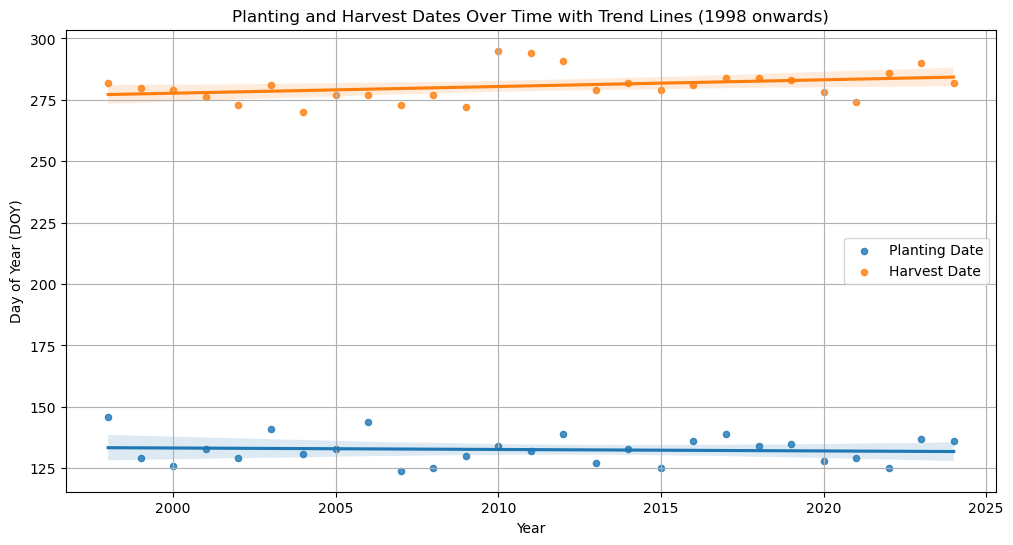

In [15]:
# Convert 'year', 'doy_planting', and 'doy_harvest' to float type for plotting
final_df['year'] = final_df['year'].astype(float)
final_df['doy_planting'] = final_df['doy_planting'].astype(float)
final_df['doy_harvest'] = final_df['doy_harvest'].astype(float)

# Filter data for years after 1998
plot_df = final_df[final_df['year'] >= 1998].copy()

# Plotting
plt.figure(figsize=(12, 6))

# Plot planting dates with a trend line
sns.regplot(x='year', y='doy_planting', data=plot_df, label='Planting Date', scatter_kws={'s': 20})

# Plot harvest dates with a trend line
sns.regplot(x='year', y='doy_harvest', data=plot_df, label='Harvest Date', scatter_kws={'s': 20})

plt.xlabel('Year')
plt.ylabel('Day of Year (DOY)')
plt.title('Planting and Harvest Dates Over Time with Trend Lines (1998 onwards)')
plt.legend() # Ensure legend is displayed
plt.grid(True)
plt.show()

In [16]:

#export
export = final_df.to_csv(os.path.join(file_path, 'planting_harvest_processed.csv'), index = False)